<a href="https://colab.research.google.com/github/Korobokkk/Kiselev_I_dsp-seminars/blob/Kiselev_4_lab/kiselel_4_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


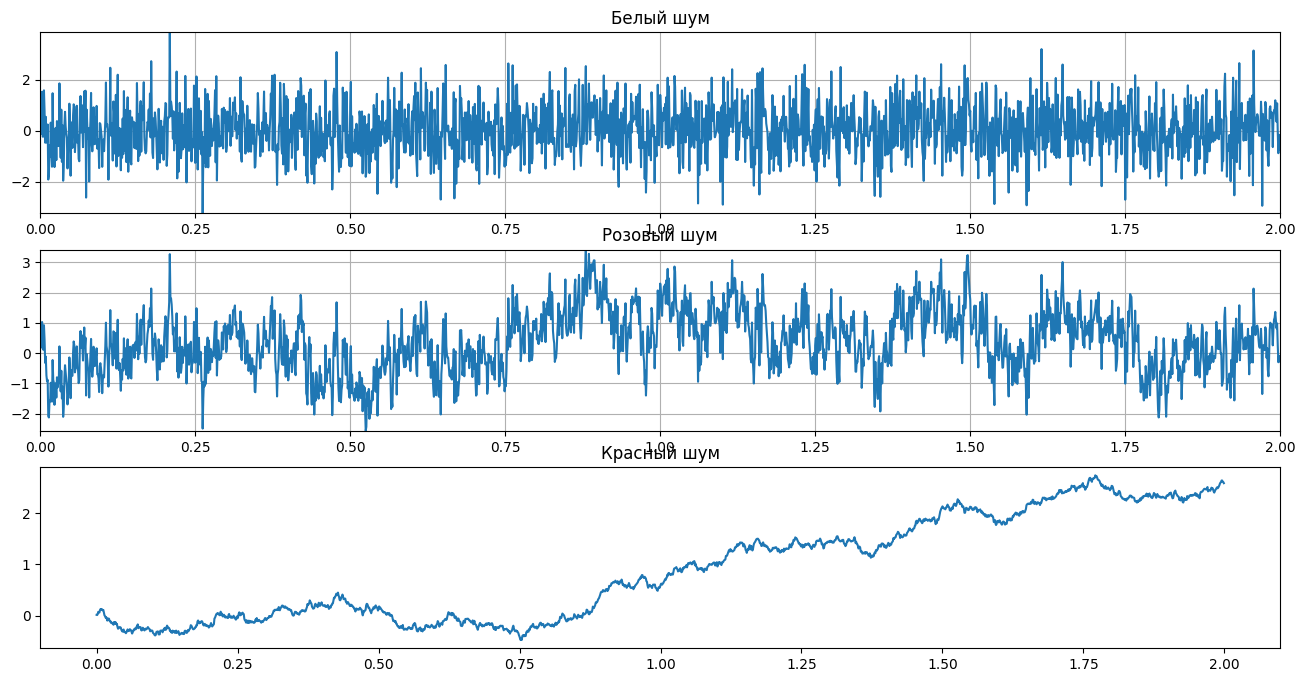

Белый шум: mean - 0.0450841465357407, disp 0.9765758247496166
Розовый шум: mean - 0.3688464579286591, disp 1.0000000000000002
Красный шум: mean - 0.8946549409027164, disp 0.9999999999999999


In [1]:
#from ast import withitem
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

T = 2
fs = 1000

scale = 1
t = np.arange(0, 2, 1 / fs  )
#white noise
white_noise = np.random.normal(0, scale, fs * T)

#pink noise
X = np.fft.rfft(white_noise)
freqs = np.fft.rfftfreq(T * fs, d = 1 / fs)
X[1:] *= 1 / np.sqrt(freqs[1:])
pink_noise = np.fft.irfft(X)
pink_noise /= np.std(pink_noise)

#red noise
red_noise = np.cumsum(white_noise)
red_noise /= np.std(red_noise)

# print(len(white_noise))
plt.figure(figsize = (16,8))
plt.subplot(3, 1, 1)
plt.title('Белый шум')
plt.plot(t, white_noise)
plt.xlim(0,2)
plt.ylim(min(white_noise),max(white_noise))
plt.grid(True)
plt.subplot(3, 1, 2)
# plt.figure(figsize = (16,8))
plt.title('Розовый шум')
plt.plot(t, pink_noise)
plt.xlim(0,2)
plt.ylim(min(pink_noise),max(pink_noise))
plt.grid(True)
plt.subplot(3, 1, 3)
# #plt.figure(figsize = (16,8))
plt.title('Красный шум')
plt.plot(t, red_noise)
plt.show()

print(f'Белый шум: mean - {np.mean(white_noise)}, disp {np.var(white_noise)}')
print(f'Розовый шум: mean - {np.mean(pink_noise)}, disp {np.var(pink_noise)}')
print(f'Красный шум: mean - {np.mean(red_noise)}, disp {np.var(red_noise)}')



**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


{Введите ваш ответ здесь}

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


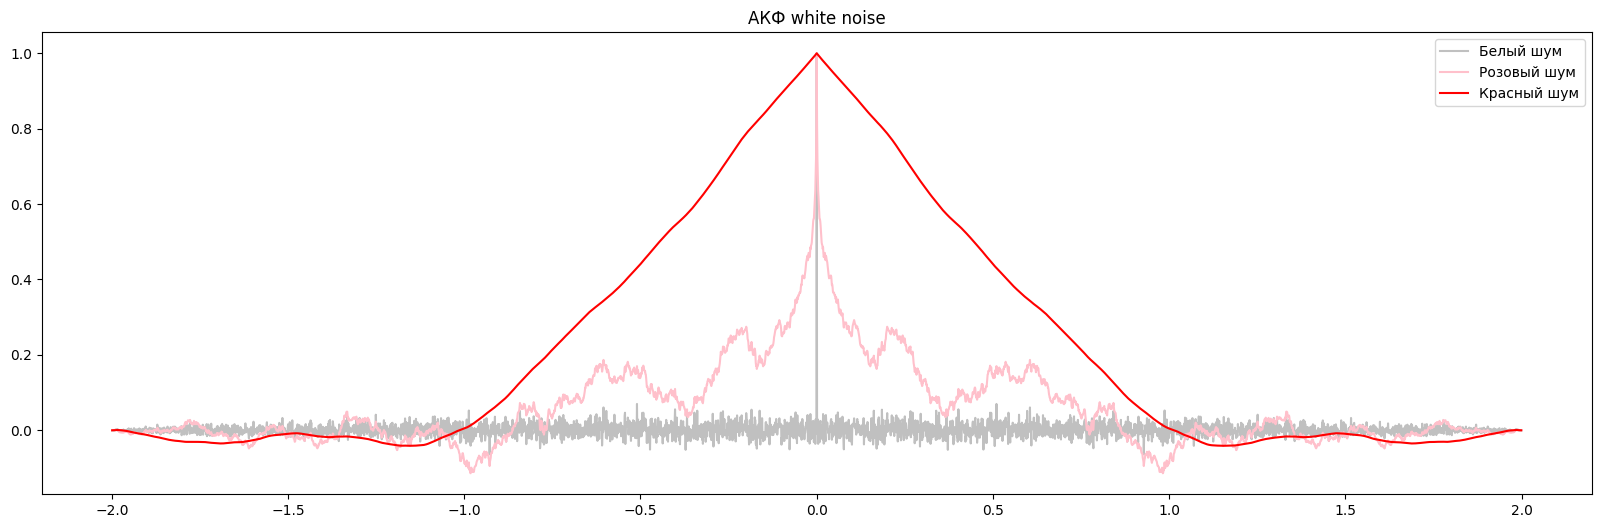

In [2]:
def corr_function(noise_signal):
  cor = np.correlate(noise_signal, noise_signal, mode = 'full')
  #print(len(cor))
  cor = cor[len(noise_signal) - 1:]
  cor /= cor[0]
  #print(len(cor))
  return cor

white_res_cor = corr_function(white_noise)
pink_res_cor = corr_function(pink_noise)
red_res_cor = corr_function(red_noise)

def symmetric_f(res_cor):
  return(np.concatenate([res_cor[:0:-1],  res_cor]))

new_range = np.arange(-(len(t)- 1), len(t))
res_range = new_range / fs
plt.figure(figsize=(20,6))
plt.title('АКФ white noise')
plt.plot(res_range, symmetric_f(white_res_cor), 'silver', label = 'Белый шум')
plt.plot(res_range, symmetric_f(pink_res_cor), color = 'pink', label = 'Розовый шум')
plt.plot(res_range, symmetric_f(red_res_cor), color = 'red', label = 'Красный шум')
#plt.ylim(np.min(white_res_cor), np.max(white_res_cor))
plt.legend()
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


{Введите ваш ответ здесь}

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


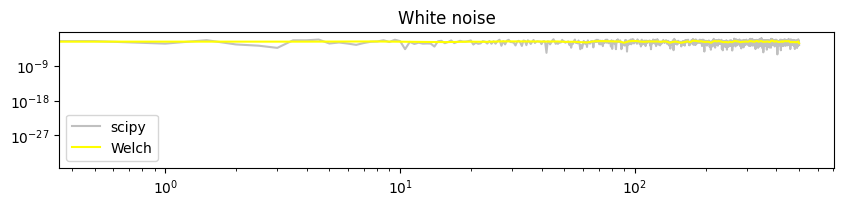

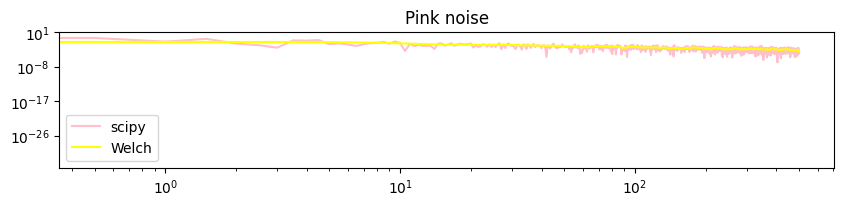

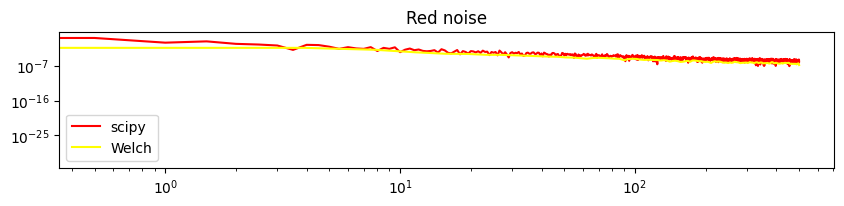

In [3]:
import scipy
f_white, arr_white = scipy.signal.periodogram(white_noise, fs)
f_white_welch, arr_white_welch = scipy.signal.welch(white_noise, fs=fs, window='hann', nperseg=256, noverlap=128)

f_pink, arr_pink = scipy.signal.periodogram(pink_noise, fs)
f_pink_welch, arr_pink_welch = scipy.signal.welch(pink_noise, fs=fs, window='hann', nperseg=256, noverlap=128)

f_red, arr_red = scipy.signal.periodogram(red_noise, fs)
f_red_welch, arr_red_welch = scipy.signal.welch(red_noise, fs=fs, window='hann', nperseg=256, noverlap=128)

plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.title('White noise')
plt.loglog(f_white, arr_white, color = 'silver', label = 'scipy')
plt.loglog(f_white_welch, arr_white_welch, color = 'yellow', label = 'Welch')
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 2)
plt.title('Pink noise')
plt.loglog(f_pink, arr_pink, color = 'pink', label = 'scipy')
plt.loglog(f_pink_welch, arr_pink_welch, color = 'yellow', label = 'Welch')
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 3)
plt.title('Red noise')
plt.loglog(f_red, arr_red, color = 'red', label = 'scipy')
plt.loglog(f_red_welch, arr_red_welch, color = 'yellow', label = 'Welch')
plt.legend()
plt.show()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


{Введите ваш ответ здесь}

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


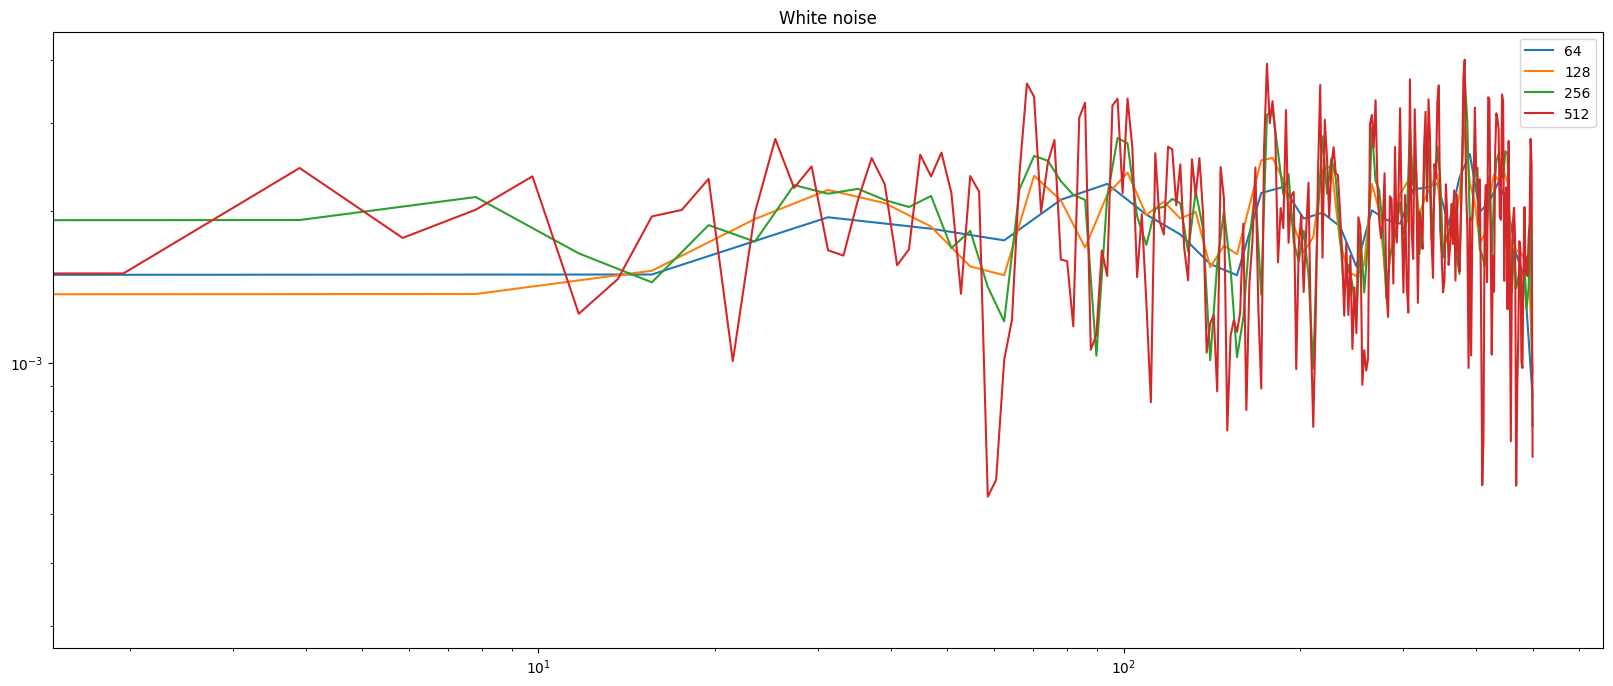

In [4]:
nperseq_arr = [64, 128, 256, 512]

plt.figure(figsize=(20, 8))
plt.title('White noise')
for n in nperseq_arr:
  f_white_welch, arr_white_welch = scipy.signal.welch(white_noise, fs=fs, window='hann', nperseg = n , noverlap = n // 2)
  plt.loglog(f_white_welch, arr_white_welch, label= f"{str(n)}")
plt.legend()
plt.draw()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


{Введите ваш ответ здесь}

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

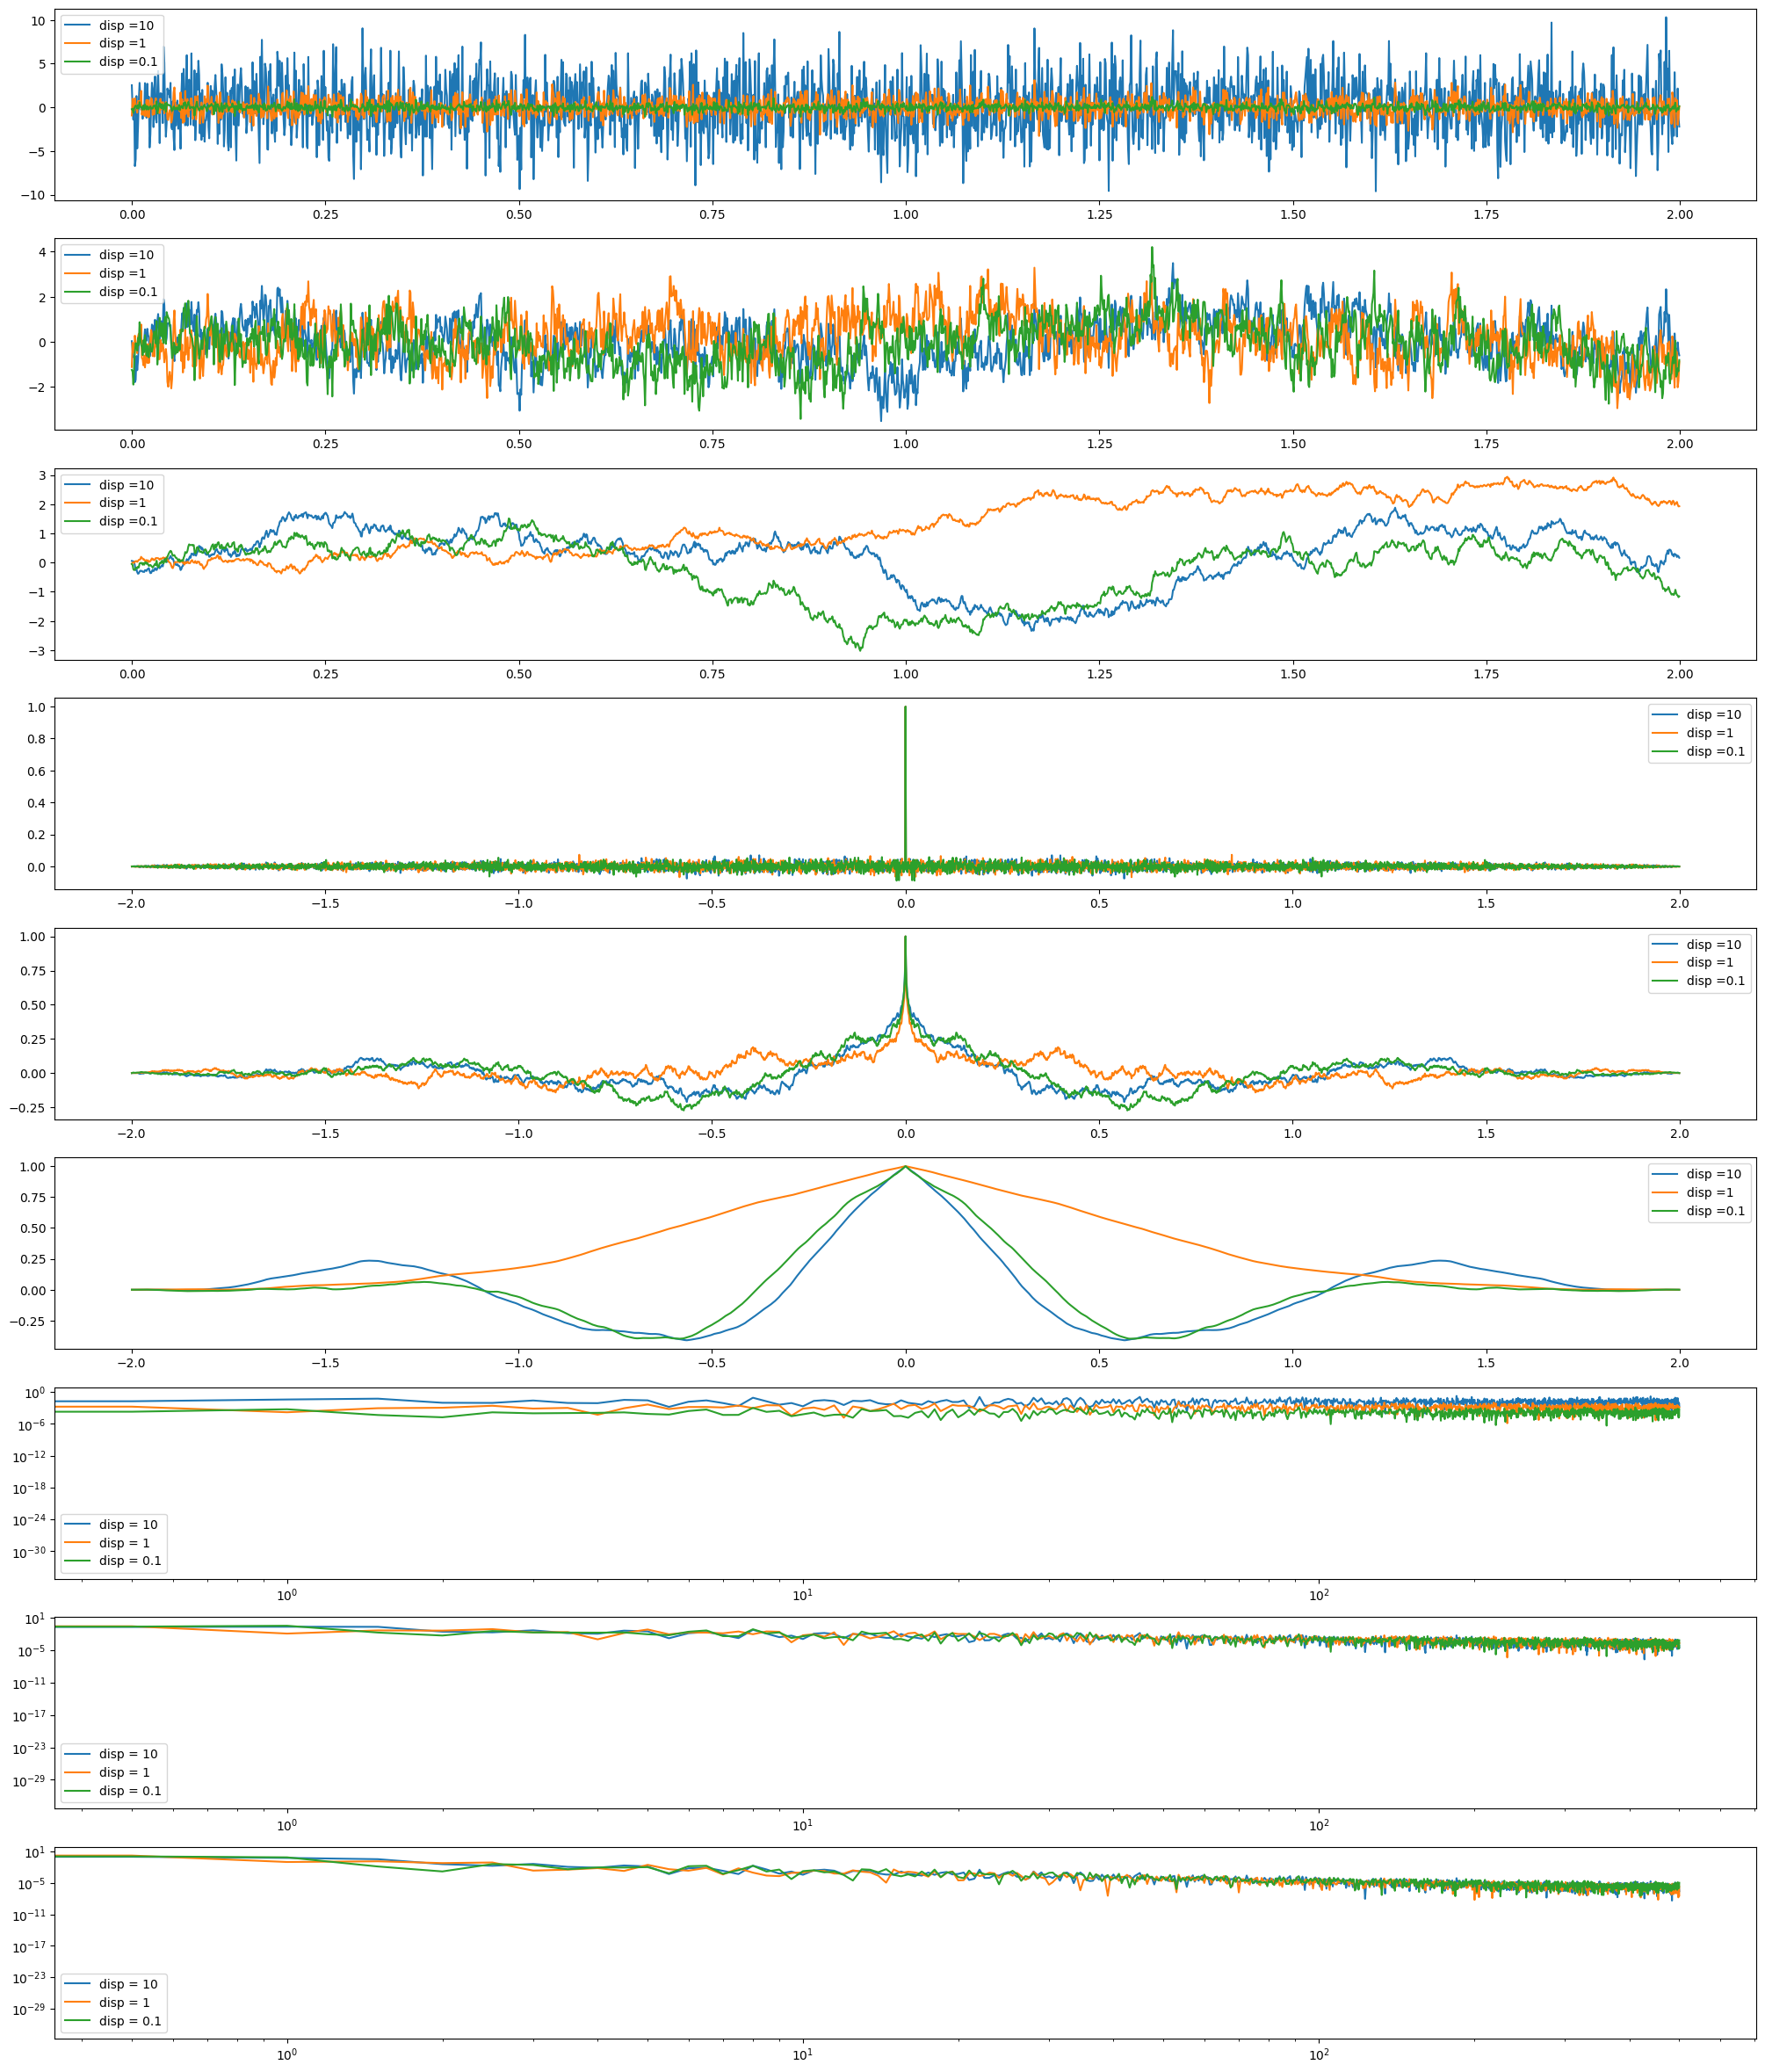

In [29]:
disp_arr = [10, 1, 0.1]

def make_signals_with_noise(disp):
  fs = 1000
  T = 2
  sigma = np.sqrt(disp)
  #WHITE
  white_n = np.random.normal(0, sigma, T * fs)
  #PINK
  X = np.fft.rfft(white_n)
  freqs = np.fft.rfftfreq(T * fs, d = 1 / fs)
  X[1:] /= np.sqrt(freqs[1:])
  pink_n = np.fft.irfft(X)
  pink_n /= np.std(pink_n)
  #RED
  red_n = np.cumsum(white_n)
  red_n /= np.std(red_n)
  return white_n,  pink_n, red_n


def corr_function(noise_signal, t):
  cor = np.correlate(noise_signal, noise_signal, mode = 'full')
  cor = cor[len(noise_signal) - 1:]
  cor /= cor[0]
  return cor

def symmetric_f(res_cor):
  return(np.concatenate([res_cor[:0:-1],  res_cor]))

def make_AKF(white, pink, red, t):
  fs = 1000
  white_res_cor = corr_function(white, t)
  pink_res_cor = corr_function(pink, t)
  red_res_cor = corr_function(red, t)

  new_range = np.arange(-(len(t)- 1), len(t))
  res_range = new_range / fs

  return res_range, symmetric_f(white_res_cor), symmetric_f(pink_res_cor), symmetric_f(red_res_cor)

# !!!
fig, axes = plt.subplots(9, 1, figsize=(25,30))
for d in disp_arr:
  #1. base
  white_noise_with_another_disp, pink_noise_with_another_disp, red_noise_with_another_disp = make_signals_with_noise(d)
  #print(white_noise_with_another_disp, pink_noise_with_another_disp, red_noise_with_another_disp)
  t = np.arange(0, 2, 1 / fs)
  #axes[0].title('Белый шум разных дисперсий')
  axes[0].plot(t, white_noise_with_another_disp, label = f'disp ={d}')
  axes[0].legend()
  axes[1].plot(t, pink_noise_with_another_disp, label = f'disp ={d}')
  axes[1].legend()
  axes[2].plot(t, red_noise_with_another_disp, label = f'disp ={d}')
  axes[2].legend()

  #2. АКФ
  res_range_akf, white_akf, pink_akf, red_akf = make_AKF(white_noise_with_another_disp, pink_noise_with_another_disp, red_noise_with_another_disp, t)
  axes[3].plot(res_range_akf, white_akf, label = f'disp ={d}')
  axes[3].legend()
  axes[4].plot(res_range_akf, pink_akf, label = f'disp ={d}')
  axes[4].legend()
  axes[5].plot(res_range_akf, red_akf, label = f'disp ={d}')
  axes[5].legend()

  #3
  f_white, arr_white = scipy.signal.periodogram(white_noise_with_another_disp, fs = 1000)
  f_pink, arr_pink = scipy.signal.periodogram(pink_noise_with_another_disp, fs = 1000)
  f_red, arr_red = scipy.signal.periodogram(red_noise_with_another_disp, fs = 1000)
  axes[6].loglog(f_white, arr_white,  label = f'disp = {d}')
  axes[6].legend()
  axes[7].loglog(f_pink, arr_pink,  label = f'disp = {d}')
  axes[7].legend()
  axes[8].loglog(f_red, arr_red, label = f'disp = {d}')
  axes[8].legend()

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


{Введите ваш ответ здесь}

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


In [6]:
# Ваш код здесь

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


{Введите ваш ответ здесь}

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


In [7]:
# Ваш код здесь

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


{Введите ваш ответ здесь}